In [1]:
import sys

sys.path.append("..")

from algo import sample_euler

### define dataset

In [2]:
import torchvision
from torch.utils.data import DataLoader, Subset

train_dataset = torchvision.datasets.MNIST(
    root="../datasets",
    train=True,
    download=True,
    transform=torchvision.transforms.PILToTensor(),
)
max_data_size = 10
subsetgen = range(max_data_size)
train_dataset_sub = Subset(train_dataset, subsetgen)

train_loader = DataLoader(train_dataset, batch_size=1152, shuffle=True)
# train_loader = DataLoader(train_dataset_sub, batch_size=32, shuffle=True)
print(f"Dataset size: {len(train_loader.dataset)}")

Dataset size: 60000


### compute

In [3]:
import matplotlib.pyplot as plt
import torch

x, y = train_loader.__iter__().__next__()
channels, height, width = x.shape[1], x.shape[2], x.shape[3]
image_size = height * width * channels
image_orginal_size = (channels, height, width)
x = x.reshape(x.shape[0], image_size) / 255.0

M = 450
# M = 100
z_0 = torch.randn(1, image_size)
sigma = 0.90
steps = 50

out = sample_euler(z_0, steps=steps, x=x, sigma=sigma, M=M)

# plt.imshow(x[5].reshape(image_orginal_size).permute(1, 2, 0), cmap="gray", vmin=0, vmax=1)
# plt.colorbar()

100%|██████████████████████████████████████████████████████████████████| 50/50 [00:57<00:00,  1.15s/it]


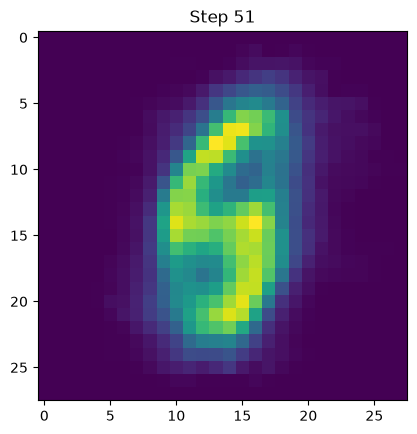

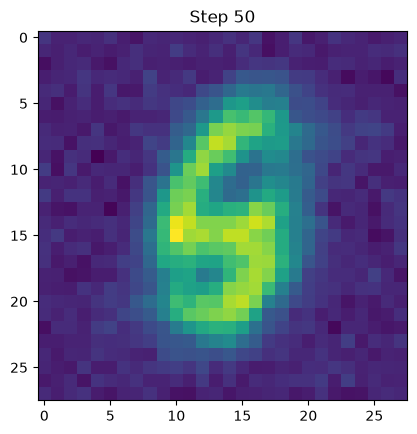

In [4]:
fig, ax = plt.subplots()
ax.imshow(out[-1].reshape(image_orginal_size).permute(1, 2, 0))
ax.set_title(f"Step {len(out)}")
plt.show()

fig, ax = plt.subplots()
ax.imshow(out[-2].reshape(image_orginal_size).permute(1, 2, 0))
ax.set_title(f"Step {len(out) - 1}")
plt.show()

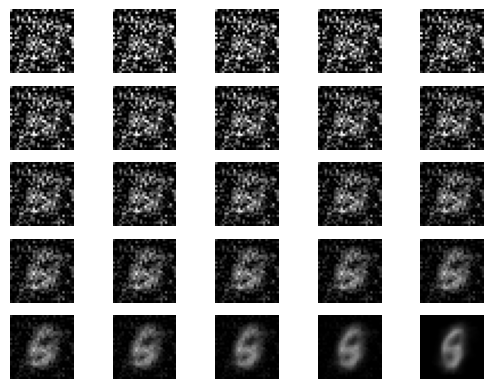

In [5]:
images = torch.stack(out[-26::])
for i in range(len(images) - 1):
    plt.subplot(5, 5, i + 1)
    plt.imshow(
        images[i + 1].reshape(image_orginal_size).permute(1, 2, 0),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    plt.axis("off")

### closest sample from dataset

100%|█████████████████████████████████████████████████████████| 60000/60000 [00:05<00:00, 10606.89it/s]


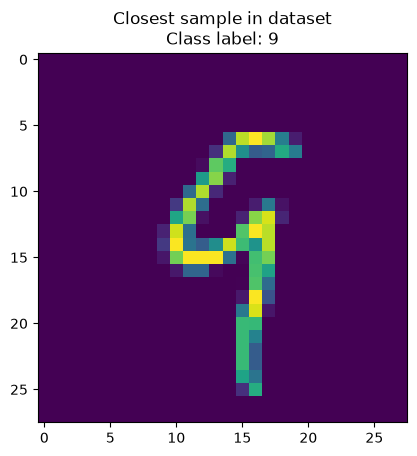

In [6]:
import numpy as np
from tqdm import tqdm

mses = []
with torch.inference_mode():
    # for sample in tqdm(pi_1):
    for sample in tqdm(train_dataset):
        mse_result = torch.nn.functional.mse_loss(
            sample[0].reshape(image_size) / 255.0, out[-1]
        ).item()
        # mse_result = torch.nn.functional.mse_loss(sample, z_journey[-1]).item()
        mses.append(mse_result)

# sample, _ = train_dataset[np.argmin(mses).item()]
sample_x, sample_y = train_dataset[np.argmin(mses).item()]
plt.imshow(sample_x.permute(1, 2, 0))
plt.title(f"Closest sample in dataset\nClass label: {sample_y}")
plt.show()

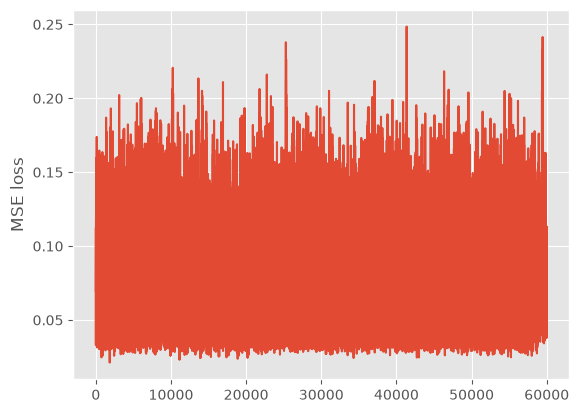

In [7]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(mses)
    ax.set_ylabel("MSE loss")
    plt.show()